Video Presentasi : https://drive.google.com/drive/folders/1gLXtv3GgQXTTP5_JKsIrGJ3qbs54DRni?usp=sharing

Ivan William Lianata - 2802461776

# Nomor 3 - Image Generation dengan Generative Adversarial Network (GAN)


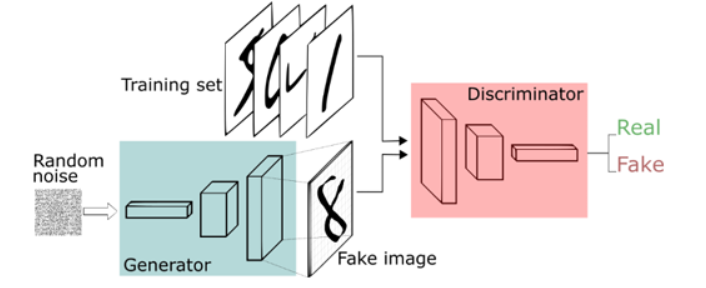

## A. Cara Kerja GAN (3a)

GAN punya dua jaringan yang dilatih bersamaan tapi tujuannya saling berlawanan.

- **Generator** bertugas menghasilkan gambar palsu (fake image). Input yang diterima Generator bukan gambar, melainkan random noise, yaitu vektor berisi angka-angka acak. Dari noise tersebut, Generator belajar memetakan menjadi sebuah gambar yang menyerupai distribusi data pada training set.

- **Discriminator** bertugas membedakan apakah suatu gambar merupakan gambar asli (real) yang berasal dari training set atau gambar palsu (fake) yang dihasilkan oleh Generator. Discriminator menerima kedua jenis gambar tersebut sebagai input, kemudian menghasilkan probabilitas atau keputusan apakah gambar tersebut real atau fake.

Proses pelatihan dilakukan secara bergantian. Pertama, Discriminator dilatih menggunakan gambar asli dan gambar palsu agar semakin akurat dalam membedakan keduanya. Setelah itu, Generator dilatih menggunakan umpan balik (loss) dari Discriminator. Jika gambar yang dihasilkan masih mudah dikenali sebagai palsu, parameter Generator akan diperbarui melalui proses backpropagation agar pada iterasi berikutnya dapat menghasilkan gambar yang lebih realistis.

Kedua jaringan ini terus berkompetisi. Discriminator berusaha meningkatkan kemampuannya dalam mendeteksi gambar palsu, sedangkan Generator berusaha menghasilkan gambar yang semakin menyerupai data asli sehingga mampu "menipu" Discriminator. Proses ini berlangsung berulang-ulang hingga Generator mampu menghasilkan gambar yang sangat realistis dan sulit dibedakan dari gambar asli. Pada kondisi ideal, Discriminator tidak lagi dapat membedakan gambar asli dan palsu dengan baik sehingga peluang prediksinya mendekati 50% (sekitar 0,5).

## Setup

In [1]:
import random
import gc
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image as PILImage

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, models, optimizers
from sklearn.model_selection import train_test_split

!pip install torch-fidelity
import torch
import torch.nn.functional as F
from torchmetrics.image.fid import FrechetInceptionDistance

try:
    from IPython.display import display
except ImportError:
    display = print

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)


def reset_seeds(seed=SEED):
    keras.backend.clear_session()
    keras.utils.set_random_seed(seed)


DATASET_DIR = Path('/kaggle/input/datasets/ivanwllm/uas-dl-3/version2')

CLASS_NAMES = ['storage_tank', 'parking_lot']
CLASS_LABELS = {name: idx for idx, name in enumerate(CLASS_NAMES)}
N_CLASSES = len(CLASS_NAMES)

IMG_SIZE = 28
IMG_SHAPE = (IMG_SIZE, IMG_SIZE, 1)
IMG_DIM = IMG_SIZE * IMG_SIZE

NOISE_DIM = 100
BATCH_SIZE = 64
EPOCHS = 50

print(f'Classes   : {CLASS_NAMES}')
print(f'Img shape : {IMG_SHAPE}  (flatten {IMG_DIM})')
print(f'Noise dim : {NOISE_DIM}', flush=True)

2026-06-26 22:09:36.764573: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1782511776.942911      58 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1782511776.996274      58 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1782511777.428458      58 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1782511777.428503      58 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1782511777.428505      58 computation_placer.cc:177] computation placer alr

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 85.6/85.6 kB 6.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.2/12.2 MB 98.8 MB/s eta 0:00:00:00:010:01
  Attempting uninstall: cuda-bindings
    Found existing installation: cuda-bindings 13.2.0
    Uninstalling cuda-bindings-13.2.0:
      Successfully uninstalled cuda-bindings-13.2.0
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
dask-cuda 26.2.0 requires cuda-core==0.3.*, but you have cuda-core 1.0.1 which is incompatible.
dask-cuda 26.2.0 requires numba-cuda<0.23.0,>=0.22.1, but you have numba-cuda 0.30.2 which is incompatible.
distributed-ucxx-cu12 0.48.0 requires numba-cuda[cu12]<0.23.0,>=0.22.1, but you have numba-cuda 0.30.2 which is incompatible.
cuml-cu12 26.2.0 requires numba<0.62.0,>=0.60.0, but you have numba 0.65.1 which is incompatible.
cuml-cu12 26.2.0 requires numba-cuda[cu12]<0.23

### Utilitas Evaluasi FID

In [ ]:
def generate_images(generator, labels, noise_dim, seed=SEED, output_range='unit'):
    rng = np.random.default_rng(seed)
    noise = rng.normal(size=(len(labels), noise_dim)).astype('float32')
    labels_arr = np.asarray(labels, dtype='int32').reshape(-1, 1)
    imgs = generator.predict([noise, labels_arr], verbose=0)
    if output_range == 'tanh':
        imgs = (imgs + 1.0) / 2.0
    return imgs


def show_generated_grid(generator, noise_dim, n_per_class=6, title='', seed=SEED, output_range='unit'):
    labels = np.concatenate([[c] * n_per_class for c in range(N_CLASSES)])
    imgs = generate_images(generator, labels, noise_dim, seed=seed, output_range=output_range)
    fig, ax = plt.subplots(N_CLASSES, n_per_class, figsize=(1.6 * n_per_class, 1.6 * N_CLASSES + 0.5))
    fig.suptitle(title)
    for i, cls in enumerate(CLASS_NAMES):
        for j in range(n_per_class):
            ax[i, j].imshow(imgs[i * n_per_class + j, ..., 0], cmap='gray', vmin=0, vmax=1)
            ax[i, j].set_xticks([]); ax[i, j].set_yticks([])
        ax[i, 0].set_ylabel(cls)
    plt.tight_layout()
    return fig


def compare_generated_grids(models_info, noise_dim, n_per_class=4, seed=SEED):
    n_models = len(models_info)
    fig, ax = plt.subplots(N_CLASSES, n_models * n_per_class,
                            figsize=(1.3 * n_per_class * n_models, 1.4 * N_CLASSES + 1))
    for m, info in enumerate(models_info):
        labels = np.concatenate([[c] * n_per_class for c in range(N_CLASSES)])
        imgs = generate_images(info['generator'], labels, noise_dim, seed=seed,
                                output_range=info.get('output_range', 'unit'))
        for i, cls in enumerate(CLASS_NAMES):
            for j in range(n_per_class):
                col = m * n_per_class + j
                ax[i, col].imshow(imgs[i * n_per_class + j, ..., 0], cmap='gray', vmin=0, vmax=1)
                ax[i, col].set_xticks([]); ax[i, col].set_yticks([])
                if j == n_per_class // 2:
                    ax[i, col].set_title(info['title'], fontsize=9)
            ax[i, 0].set_ylabel(cls)
    plt.tight_layout()
    return fig


def _to_inception(imgs_nhwc):
    # (N, 28, 28, 1) float [0,1] -> (N, 3, 299, 299) float [0,1] sesuai input InceptionV3
    t = torch.tensor(imgs_nhwc).permute(0, 3, 1, 2)
    t = F.interpolate(t, size=(299, 299), mode='bilinear', align_corners=False)
    return t.repeat(1, 3, 1, 1).clamp(0, 1)

_FID_METRIC = None

def compute_fid(real_images, fake_images, batch_size=64):
    global _FID_METRIC
    if _FID_METRIC is None:
        _FID_METRIC = FrechetInceptionDistance(feature=2048, normalize=True)
    fid = _FID_METRIC
    fid.reset()
    with torch.no_grad():
        for i in range(0, len(real_images), batch_size):
            fid.update(_to_inception(real_images[i:i + batch_size]), real=True)
        for i in range(0, len(fake_images), batch_size):
            fid.update(_to_inception(fake_images[i:i + batch_size]), real=False)
    score = float(fid.compute())
    fid.reset()
    gc.collect()
    return score


def evaluate_fid(generator, X_real, y_real, noise_dim, name='', output_range='unit'):
    fake = generate_images(generator, y_real, noise_dim, output_range=output_range)
    score = compute_fid(X_real, fake)
    print(f'{name:34s}: FID = {score:.2f}', flush=True)
    return score

## B. Persiapan Data

Citra di-load sebagai grayscale 28x28 lalu dibagi 255 supaya nilainya berada di rentang 0 sampai 1.
Data dipisah menjadi 80 persen training, 10 persen validation, dan 10 persen test.

In [3]:
VALID_EXT = {'.jpg', '.jpeg'}
records = []
for split in ['train', 'test']:
    for class_name in CLASS_NAMES:
        class_dir = DATASET_DIR / split / class_name
        files = sorted(f for f in class_dir.iterdir() if f.suffix.lower() in VALID_EXT)
        print(f'  {split:9s} {class_name:15s}: {len(files):>4} gambar')
        for f in files:
            records.append({'path': str(f), 'label': CLASS_LABELS[class_name]})

df_meta = pd.DataFrame(records)
print(f'\nTotal gambar: {len(df_meta)}', flush=True)


def load_images(paths, img_size=IMG_SIZE):
    images = np.zeros((len(paths), img_size, img_size, 1), dtype=np.float32)
    for i, p in enumerate(paths):
        img = PILImage.open(p).convert('L').resize((img_size, img_size))
        images[i, ..., 0] = np.array(img, dtype=np.float32)
    return images / 255.0


X = load_images(df_meta['path'].values)
y = df_meta['label'].values
print(f'X shape : {X.shape}, range [{X.min():.2f}, {X.max():.2f}]', flush=True)

  train     storage_tank   : 7121 gambar
  train     parking_lot    : 7111 gambar
  test      storage_tank   :  888 gambar
  test      parking_lot    :  896 gambar

Total gambar: 16016
X shape : (16016, 28, 28, 1), range [0.00, 1.00]


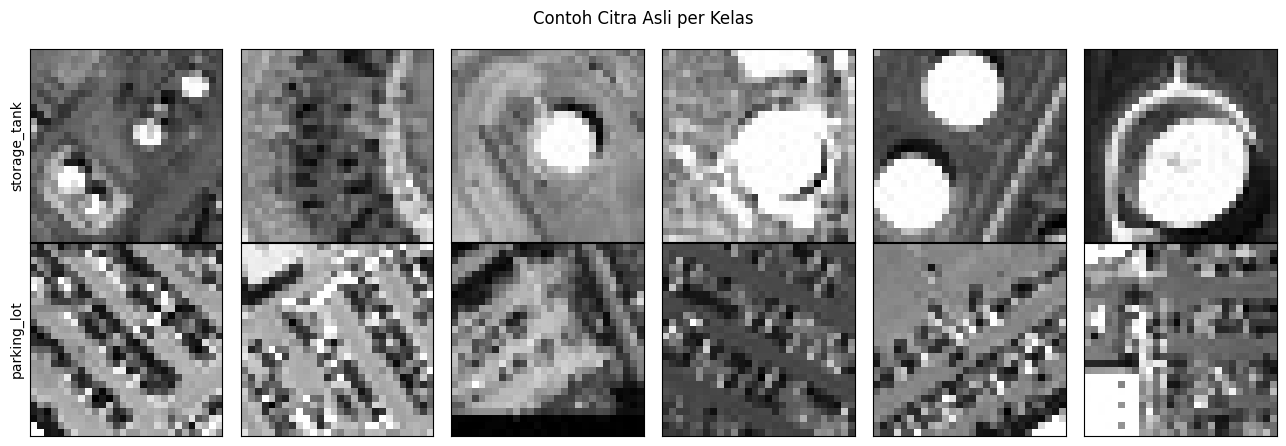

In [4]:
fig, ax = plt.subplots(N_CLASSES, 6, figsize=(13, 4.5))
fig.suptitle('Contoh Citra Asli per Kelas')
for i, cls in enumerate(CLASS_NAMES):
    idx = np.where(y == CLASS_LABELS[cls])[0]
    for j, s in enumerate(np.random.choice(idx, 6, replace=False)):
        ax[i, j].imshow(X[s, ..., 0], cmap='gray')
        ax[i, j].set_xticks([]); ax[i, j].set_yticks([])
    ax[i, 0].set_ylabel(cls)
plt.tight_layout()
plt.show()

In [5]:
X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.2, random_state=SEED, stratify=y)
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.5, random_state=SEED, stratify=y_temp)
print(f'Train : {len(X_train)}')
print(f'Val   : {len(X_val)}')
print(f'Test  : {len(X_test)}', flush=True)

Train : 12812
Val   : 1602
Test  : 1602


## C. GAN Baseline sesuai Diagram (3b)

### C.1 Arsitektur Generator dan Discriminator

In [6]:
def build_generator(noise_dim=NOISE_DIM, name='Generator'):
    noise_in = layers.Input(shape=(noise_dim,), name='noise')
    label_in = layers.Input(shape=(1,), dtype='int32', name='label')
    label_emb = layers.Flatten()(layers.Embedding(N_CLASSES, N_CLASSES)(label_in))

    x = layers.Concatenate()([noise_in, label_emb])
    for units in (128, 256, 512, 1024):
        x = layers.Dense(units)(x)
        x = layers.Activation('relu')(x)

    x = layers.Dense(IMG_DIM, activation='sigmoid')(x)
    img_out = layers.Reshape(IMG_SHAPE)(x)
    return models.Model([noise_in, label_in], img_out, name=name)


def build_discriminator(name='Discriminator'):
    img_in = layers.Input(shape=IMG_SHAPE, name='image')
    label_in = layers.Input(shape=(1,), dtype='int32', name='label')
    label_emb = layers.Flatten()(layers.Embedding(N_CLASSES, N_CLASSES)(label_in))

    x = layers.Concatenate()([layers.Flatten()(img_in), label_emb])
    for units in (512, 1024, 1024, 512):
        x = layers.Dense(units)(x)
        x = layers.Activation('relu')(x)

    out = layers.Dense(1, activation='sigmoid')(x)
    return models.Model([img_in, label_in], out, name=name)


reset_seeds(SEED)
gen_baseline = build_generator(name='Generator_Baseline')
disc_baseline = build_discriminator(name='Discriminator_Baseline')
gen_baseline.summary()
disc_baseline.summary()

I0000 00:00:1782511945.118938      58 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13756 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1782511945.121623      58 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13756 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


Model: "Generator_Baseline"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ label (InputLayer)  │ (None, 1)         │          0 │ -                 │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ embedding           │ (None, 1, 2)      │          4 │ label[0][0]       │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ noise (InputLayer)  │ (None, 100)       │          0 │ -                 │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ flatten (Flatten)   │ (None, 2)         │          0 │ embedding[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate         │ (None, 102)       │          0 │ noise[0][0],      │
│ (Concatenate)       │                   │            │ flatten[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 128)       │     13,184 │ concatenate[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation          │ (None, 128)       │          0 │ dense[0][0]       │
│ (Activation)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_1 (Dense)     │ (None, 256)       │     33,024 │ activation[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_1        │ (None, 256)       │          0 │ dense_1[0][0]     │
│ (Activation)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_2 (Dense)     │ (None, 512)       │    131,584 │ activation_1[0][… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_2        │ (None, 512)       │          0 │ dense_2[0][0]     │
│ (Activation)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_3 (Dense)     │ (None, 1024)      │    525,312 │ activation_2[0][… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_3        │ (None, 1024)      │          0 │ dense_3[0][0]     │
│ (Activation)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_4 (Dense)     │ (None, 784)       │    803,600 │ activation_3[0][… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ reshape (Reshape)   │ (None, 28, 28, 1) │          0 │ dense_4[0][0]     │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 1,506,708 (5.75 MB)

 Trainable params: 1,506,708 (5.75 MB)

...

Model: "Discriminator_Baseline"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ label (InputLayer)  │ (None, 1)         │          0 │ -                 │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ image (InputLayer)  │ (None, 28, 28, 1) │          0 │ -                 │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ embedding_1         │ (None, 1, 2)      │          4 │ label[0][0]       │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ flatten_2 (Flatten) │ (None, 784)       │          0 │ image[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ flatten_1 (Flatten) │ (None, 2)         │          0 │ embedding_1[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate_1       │ (None, 786)       │          0 │ flatten_2[0][0],  │
│ (Concatenate)       │                   │            │ flatten_1[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_5 (Dense)     │ (None, 512)       │    402,944 │ concatenate_1[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_4        │ (None, 512)       │          0 │ dense_5[0][0]     │
│ (Activation)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_6 (Dense)     │ (None, 1024)      │    525,312 │ activation_4[0][… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_5        │ (None, 1024)      │          0 │ dense_6[0][0]     │
│ (Activation)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_7 (Dense)     │ (None, 1024)      │  1,049,600 │ activation_5[0][… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_6        │ (None, 1024)      │          0 │ dense_7[0][0]     │
│ (Activation)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_8 (Dense)     │ (None, 512)       │    524,800 │ activation_6[0][… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_7        │ (None, 512)       │          0 │ dense_8[0][0]     │
│ (Activation)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_9 (Dense)     │ (None, 1)         │        513 │ activation_7[0][… │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 2,503,173 (9.55 MB)

 Trainable params: 2,503,173 (9.55 MB)

 Non-trainable params: 0 (0.00 B)

### C.2 Training Loop

In [7]:
bce = keras.losses.BinaryCrossentropy()


def discriminator_loss(real_pred, fake_pred):
    return bce(tf.ones_like(real_pred), real_pred) + bce(tf.zeros_like(fake_pred), fake_pred)


def generator_loss(fake_pred):
    return bce(tf.ones_like(fake_pred), fake_pred)


def train_gan(generator, discriminator, X_tr, y_tr, noise_dim=NOISE_DIM, epochs=EPOCHS,
              batch_size=BATCH_SIZE, lr_gen=2e-4, lr_disc=2e-4, beta_1=0.5, verbose_every=20):
    gen_opt = optimizers.Adam(lr_gen, beta_1=beta_1)
    disc_opt = optimizers.Adam(lr_disc, beta_1=beta_1)

    @tf.function
    def train_step(real_images, real_labels):
        bsize = tf.shape(real_images)[0]
        noise = tf.random.normal([bsize, noise_dim])
        fake_labels = tf.random.uniform([bsize, 1], maxval=N_CLASSES, dtype=tf.int32)

        with tf.GradientTape() as disc_tape:
            fake_images = generator([noise, fake_labels], training=True)
            real_pred = discriminator([real_images, real_labels], training=True)
            fake_pred = discriminator([fake_images, fake_labels], training=True)
            d_loss = discriminator_loss(real_pred, fake_pred)
        disc_grads = disc_tape.gradient(d_loss, discriminator.trainable_variables)
        disc_opt.apply_gradients(zip(disc_grads, discriminator.trainable_variables))

        with tf.GradientTape() as gen_tape:
            fake_images = generator([noise, fake_labels], training=True)
            fake_pred = discriminator([fake_images, fake_labels], training=True)
            g_loss = generator_loss(fake_pred)
        gen_grads = gen_tape.gradient(g_loss, generator.trainable_variables)
        gen_opt.apply_gradients(zip(gen_grads, generator.trainable_variables))
        return d_loss, g_loss

    ds = tf.data.Dataset.from_tensor_slices((X_tr, y_tr.reshape(-1, 1).astype('int32')))
    ds = ds.shuffle(len(X_tr), seed=SEED).batch(batch_size, drop_remainder=True)

    history = {'d_loss': [], 'g_loss': []}
    for epoch in range(1, epochs + 1):
        d_losses, g_losses = [], []
        for real_images, real_labels in ds:
            d_loss, g_loss = train_step(real_images, real_labels)
            d_losses.append(float(d_loss)); g_losses.append(float(g_loss))
        history['d_loss'].append(np.mean(d_losses))
        history['g_loss'].append(np.mean(g_losses))
        if epoch % verbose_every == 0 or epoch == epochs:
            print(f'  Epoch {epoch:>4}/{epochs}  d_loss={history["d_loss"][-1]:.4f}  g_loss={history["g_loss"][-1]:.4f}', flush=True)
    return history

In [8]:
print('=== Training Baseline GAN ===', flush=True)
hist_baseline = train_gan(gen_baseline, disc_baseline, X_train, y_train, lr_gen=2e-4, lr_disc=2e-4, beta_1=0.5)

=== Training Baseline GAN ===
  Epoch   20/50  d_loss=1.1390  g_loss=1.1812
  Epoch   40/50  d_loss=1.2441  g_loss=1.0466
  Epoch   50/50  d_loss=1.2408  g_loss=1.0423


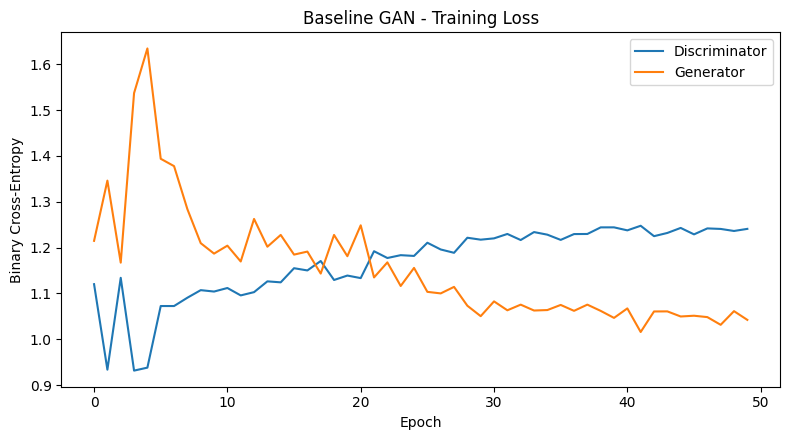

In [9]:
fig = plt.figure(figsize=(8, 4.5))
plt.plot(hist_baseline['d_loss'], label='Discriminator')
plt.plot(hist_baseline['g_loss'], label='Generator')
plt.title('Baseline GAN - Training Loss')
plt.xlabel('Epoch'); plt.ylabel('Binary Cross-Entropy')
plt.legend(); plt.tight_layout()
plt.show()

Grafik Baseline GAN menunjukkan pelatihan yang tidak sehat karena Generator terlalu mendominasi Discriminator setelah epoch ke-20. Kondisi ini merupakan indikator kuat terjadinya mode collapse, yang berdampak buruk dalam jangka panjang karena model berhenti belajar dan hanya akan menghasilkan gambar sintetik yang monoton tanpa variasi.

### C.3 Evaluasi FID dan Contoh Citra

In [10]:
fid_baseline = evaluate_fid(gen_baseline, X_test, y_test, NOISE_DIM, name='Baseline (test)')

I0000 00:00:1782512037.124721     146 service.cc:152] XLA service 0x346a9530 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1782512037.124761     146 service.cc:160]   StreamExecutor device (0): Tesla T4, Compute Capability 7.5
I0000 00:00:1782512037.124765     146 service.cc:160]   StreamExecutor device (1): Tesla T4, Compute Capability 7.5
I0000 00:00:1782512037.230124     146 cuda_dnn.cc:529] Loaded cuDNN version 91002
I0000 00:00:1782512037.582014     146 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.
Downloading: "https://github.com/toshas/torch-fidelity/releases/download/v0.2.0/weights-inception-2015-12-05-6726825d.pth" to /root/.cache/torch/hub/checkpoints/weights-inception-2015-12-05-6726825d.pth
100%|██████████| 91.2M/91.2M [00:00<00:00, 327MB/s]


Baseline (test)                   : FID = 285.39


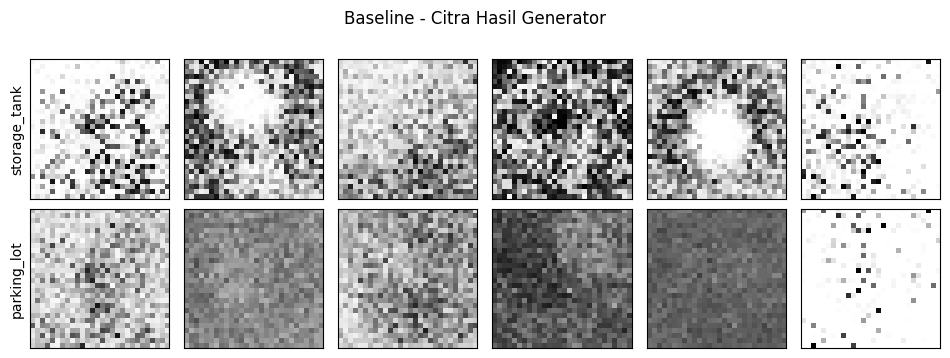

In [11]:
fig = show_generated_grid(gen_baseline, NOISE_DIM, title='Baseline - Citra Hasil Generator')
plt.show()

**FID Baseline = 285.39** pada test set, tergolong tinggi. Dari contoh visual:
- Citra yang dihasilkan cenderung homogen dan buram
- Tidak ada struktur spasial yang jelas antara kelas `storage_tank` maupun `parking_lot`
 
Ini konsisten dengan keterbatasan `Dense` yang memperlakukan tiap piksel secara independen.
Nilai ini menjadi acuan yang perlu diturunkan oleh DCGAN di bagian D.

## D. Modifikasi Arsitektur & Tuning Hyperparameter (3c)

**Modifikasi arsitektur (D.1): Dense diganti jadi DCGAN (Conv2DTranspose / Conv2D)**

| Bagian | Baseline | Modifikasi | Alasan |
|---|---|---|---|
| Tipe layer | `Dense` di semua tempat | `Conv2DTranspose` di Generator, `Conv2D` di Discriminator | `Dense` memperlakukan tiap piksel sebagai fitur berdiri sendiri sehingga sulit menangkap pola spasial (tepi, tekstur). Konvolusi punya bias spasial yang jauh lebih cocok untuk citra: filter yang sama dipakai ulang di seluruh posisi sehingga lebih efisien mempelajari pola lokal. |
| Normalisasi | tidak ada | `BatchNormalization` di **semua** layer hidden Generator, dan di layer hidden **lanjutan** Discriminator (layer pertama Discriminator sengaja dilewatkan, sesuai rekomendasi paper DCGAN, supaya statistik citra mentah tidak langsung dinormalisasi) | Menjaga aliran gradien tetap stabil antar layer, mengurangi risiko training kolaps. |
| Regularisasi Discriminator | tidak ada | `Dropout(0.3)` di tiap blok konvolusi | Menahan Discriminator supaya tidak terlalu cepat menang. Kalau Discriminator terlalu kuat, gradien yang sampai ke Generator mendekati nol. |
| Aktivasi output Generator | `Sigmoid`, citra di rentang [0, 1] | `Tanh`, citra di rentang [-1, 1] | Gradien `Tanh` lebih kuat dan simetris di sekitar nol dibanding `Sigmoid`, secara empiris membantu DCGAN belajar lebih stabil dan lebih cepat. |
| Learning rate (TTUR) | `lr_gen = lr_disc = 2e-4` | `lr_gen = 1e-4`, `lr_disc = 4e-4` | *Two Time-Scale Update Rule*: Discriminator diberi langkah belajar lebih besar daripada Generator supaya penilai selalu sedikit "lebih maju", memberi sinyal gradien yang lebih informatif buat Generator dibanding kalau keduanya belajar sama cepat. |

Karena Generator sekarang berakhir di `Tanh` (rentang [-1, 1]), citra training asli yang dipakai untuk
melatih model ini juga diskalakan ulang ke rentang yang sama (`X_train_tanh = X_train * 2 - 1`), supaya
Discriminator membandingkan citra asli dan citra palsu pada skala yang konsisten. Citra untuk evaluasi
FID (`X_val`, `X_test`) tidak diubah (tetap di [0, 1]) karena FID butuh skala itu; citra buatan
Generator yang dikembalikan ke [0, 1] sebelum dibandingkan (lihat parameter `output_range='tanh'` pada
`evaluate_fid`/`generate_images`).

### D.1 Modifikasi Arsitektur: DCGAN

In [12]:
X_train_tanh = (X_train * 2.0 - 1.0).astype('float32')


def build_generator_dcgan(noise_dim=NOISE_DIM, name='Generator_DCGAN'):
    noise_in = layers.Input(shape=(noise_dim,), name='noise')
    label_in = layers.Input(shape=(1,), dtype='int32', name='label')
    label_emb = layers.Flatten()(layers.Embedding(N_CLASSES, N_CLASSES)(label_in))

    x = layers.Concatenate()([noise_in, label_emb])
    x = layers.Dense(7 * 7 * 256)(x)
    x = layers.Reshape((7, 7, 256))(x)
    x = layers.BatchNormalization()(x)
    x = layers.LeakyReLU(0.2)(x)

    x = layers.Conv2DTranspose(128, 4, strides=2, padding='same')(x)   # 7x7 -> 14x14
    x = layers.BatchNormalization()(x)
    x = layers.LeakyReLU(0.2)(x)

    x = layers.Conv2DTranspose(64, 4, strides=2, padding='same')(x)    # 14x14 -> 28x28
    x = layers.BatchNormalization()(x)
    x = layers.LeakyReLU(0.2)(x)

    img_out = layers.Conv2D(1, 3, padding='same', activation='tanh')(x)
    return models.Model([noise_in, label_in], img_out, name=name)


def build_discriminator_dcgan(name='Discriminator_DCGAN'):
    img_in = layers.Input(shape=IMG_SHAPE, name='image')
    label_in = layers.Input(shape=(1,), dtype='int32', name='label')
    label_map = layers.Reshape(IMG_SHAPE)(layers.Embedding(N_CLASSES, IMG_DIM)(label_in))

    x = layers.Concatenate(axis=-1)([img_in, label_map])

    x = layers.Conv2D(64, 4, strides=2, padding='same')(x)             # layer pertama: tanpa BatchNorm
    x = layers.LeakyReLU(0.2)(x)
    x = layers.Dropout(0.3)(x)

    x = layers.Conv2D(128, 4, strides=2, padding='same')(x)            # layer lanjutan: dengan BatchNorm
    x = layers.BatchNormalization()(x)
    x = layers.LeakyReLU(0.2)(x)
    x = layers.Dropout(0.3)(x)

    x = layers.Flatten()(x)
    out = layers.Dense(1, activation='sigmoid')(x)
    return models.Model([img_in, label_in], out, name=name)


reset_seeds(SEED)
gen_mod = build_generator_dcgan(name='Generator_Modified')
disc_mod = build_discriminator_dcgan(name='Discriminator_Modified')
gen_mod.summary()
disc_mod.summary()

print('=== Training Modified GAN (DCGAN, TTUR lr_gen=1e-4 / lr_disc=4e-4) ===', flush=True)
hist_mod = train_gan(gen_mod, disc_mod, X_train_tanh, y_train, lr_gen=1e-4, lr_disc=4e-4, beta_1=0.5)
fid_mod_val = evaluate_fid(gen_mod, X_val, y_val, NOISE_DIM, name='Modified, sebelum tuning (val)', output_range='tanh')

Model: "Generator_Modified"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ label (InputLayer)  │ (None, 1)         │          0 │ -                 │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ embedding           │ (None, 1, 2)      │          4 │ label[0][0]       │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ noise (InputLayer)  │ (None, 100)       │          0 │ -                 │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ flatten (Flatten)   │ (None, 2)         │          0 │ embedding[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate         │ (None, 102)       │          0 │ noise[0][0],      │
│ (Concatenate)       │                   │            │ flatten[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 12544)     │  1,292,032 │ concatenate[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ reshape (Reshape)   │ (None, 7, 7, 256) │          0 │ dense[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalization │ (None, 7, 7, 256) │      1,024 │ reshape[0][0]     │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ leaky_re_lu         │ (None, 7, 7, 256) │          0 │ batch_normalizat… │
│ (LeakyReLU)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_transpose    │ (None, 14, 14,    │    524,416 │ leaky_re_lu[0][0] │
│ (Conv2DTranspose)   │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 14, 14,    │        512 │ conv2d_transpose… │
│ (BatchNormalizatio… │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ leaky_re_lu_1       │ (None, 14, 14,    │          0 │ batch_normalizat… │
│ (LeakyReLU)         │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_transpose_1  │ (None, 28, 28,    │    131,136 │ leaky_re_lu_1[0]… │
│ (Conv2DTranspose)   │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 28, 28,    │        256 │ conv2d_transpose… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ leaky_re_lu_2       │ (None, 28, 28,    │          0 │ batch_normalizat… │
│ (LeakyReLU)         │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d (Conv2D)     │ (None, 28, 28, 1) │        577 │ leaky_re_lu_2[0]… │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 1,949,957 (7.44 MB)

 Trainable params: 1,949,061 (7.44 MB)

 Non-trainable params: 896 (3.50 KB)

...

 Trainable params: 141,409 (552.38 KB)

 Non-trainable params: 256 (1.00 KB)

=== Training Modified GAN (DCGAN, TTUR lr_gen=1e-4 / lr_disc=4e-4) ===


E0000 00:00:1782512519.397201      58 meta_optimizer.cc:967] layout failed: INVALID_ARGUMENT: Size of values 0 does not match size of permutation 4 @ fanin shape inDiscriminator_Modified_1/dropout_1/stateless_dropout/SelectV2-2-TransposeNHWCToNCHW-LayoutOptimizer


  Epoch   20/50  d_loss=1.0133  g_loss=1.5040
  Epoch   40/50  d_loss=1.0978  g_loss=1.5891
  Epoch   50/50  d_loss=1.1606  g_loss=1.2856
Modified, sebelum tuning (val)    : FID = 166.72


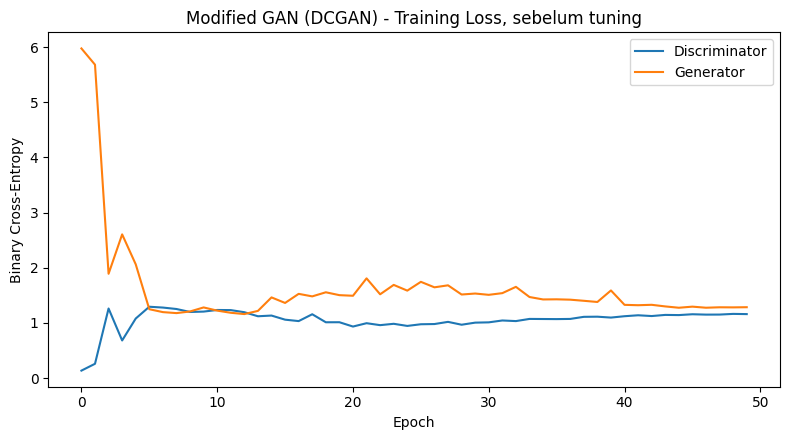

In [13]:
fig = plt.figure(figsize=(8, 4.5))
plt.plot(hist_mod['d_loss'], label='Discriminator')
plt.plot(hist_mod['g_loss'], label='Generator')
plt.title('Modified GAN (DCGAN) - Training Loss, sebelum tuning')
plt.xlabel('Epoch'); plt.ylabel('Binary Cross-Entropy')
plt.legend(); plt.tight_layout()
plt.show()

Grafik Modified GAN (DCGAN) menunjukkan pelatihan yang stabil dan sehat karena pergerakan loss Generator dan Discriminator cenderung seimbang dan paralel setelah epoch ke-10. Persaingan yang proporsional ini berdampak positif karena memastikan model terhindar dari mode collapse, sehingga mampu menghasilkan variasi gambar yang jauh lebih realistis.
 

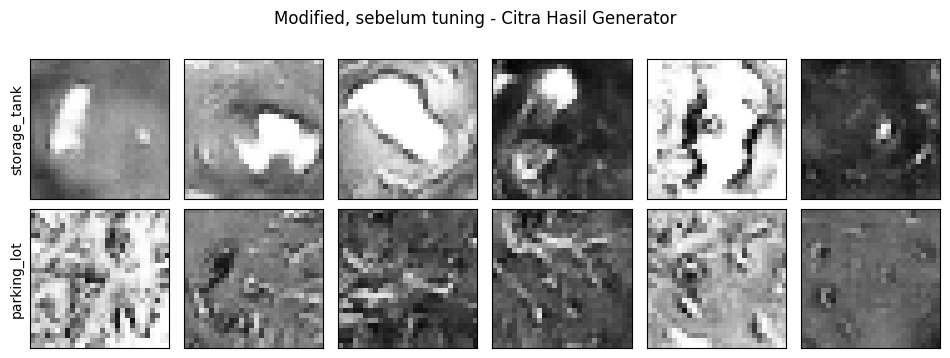

In [14]:
fig = show_generated_grid(gen_mod, NOISE_DIM, title='Modified, sebelum tuning - Citra Hasil Generator', output_range='tanh')
plt.show()

Dibanding Baseline, citra yang dihasilkan sudah menunjukkan struktur yang lebih jelas:
- Bentuk lingkaran mulai terlihat pada `storage_tank`
- Pola berulang mulai terbentuk pada `parking_lot`
 
Namun detail masih kasar dan belum konsisten antar sampel, menunjukkan Generator
belum optimal dan masih bisa ditingkatkan lewat tuning hyperparameter di D.2.
 

### D.2 Tuning Hyperparameter

In [15]:
lr_candidates = [(1e-4, 4e-4), (1e-4, 2e-4), (2e-4, 4e-4)]
tuned_models = {(1e-4, 4e-4): (gen_mod, disc_mod)}
tuning_rows = [{'lr_gen': 1e-4, 'lr_disc': 4e-4, 'FID (val)': fid_mod_val}]

for lr_gen, lr_disc in lr_candidates:
    if (lr_gen, lr_disc) == (1e-4, 4e-4):
        continue
    print(f'\n=== Tuning lr_gen={lr_gen:.0e}, lr_disc={lr_disc:.0e} ===', flush=True)
    reset_seeds(SEED)
    g = build_generator_dcgan(name=f'Generator_g{lr_gen:.0e}_d{lr_disc:.0e}')
    d = build_discriminator_dcgan(name=f'Discriminator_g{lr_gen:.0e}_d{lr_disc:.0e}')
    train_gan(g, d, X_train_tanh, y_train, lr_gen=lr_gen, lr_disc=lr_disc, beta_1=0.5)
    fid_val = evaluate_fid(g, X_val, y_val, NOISE_DIM,
                            name=f'lr_gen={lr_gen:.0e}, lr_disc={lr_disc:.0e} (val)', output_range='tanh')
    tuned_models[(lr_gen, lr_disc)] = (g, d)
    tuning_rows.append({'lr_gen': lr_gen, 'lr_disc': lr_disc, 'FID (val)': fid_val})

df_tuning = pd.DataFrame(tuning_rows)
print('\n', df_tuning.to_string(index=False), flush=True)


=== Tuning lr_gen=1e-04, lr_disc=2e-04 ===


E0000 00:00:1782513319.810884      58 meta_optimizer.cc:967] layout failed: INVALID_ARGUMENT: Size of values 0 does not match size of permutation 4 @ fanin shape inDiscriminator_g1e-04_d2e-04_1/dropout_1/stateless_dropout/SelectV2-2-TransposeNHWCToNCHW-LayoutOptimizer


  Epoch   20/50  d_loss=1.2368  g_loss=0.9581
  Epoch   40/50  d_loss=1.2013  g_loss=1.0335
  Epoch   50/50  d_loss=1.2080  g_loss=1.0583
lr_gen=1e-04, lr_disc=2e-04 (val) : FID = 155.18

=== Tuning lr_gen=2e-04, lr_disc=4e-04 ===


E0000 00:00:1782514135.583542      58 meta_optimizer.cc:967] layout failed: INVALID_ARGUMENT: Size of values 0 does not match size of permutation 4 @ fanin shape inDiscriminator_g2e-04_d4e-04_1/dropout_1/stateless_dropout/SelectV2-2-TransposeNHWCToNCHW-LayoutOptimizer


  Epoch   20/50  d_loss=1.2882  g_loss=0.9952
  Epoch   40/50  d_loss=1.3157  g_loss=0.9189
  Epoch   50/50  d_loss=1.3359  g_loss=0.8799
lr_gen=2e-04, lr_disc=4e-04 (val) : FID = 141.81

  lr_gen  lr_disc  FID (val)
 0.0001   0.0004 166.718658
 0.0001   0.0002 155.177963
 0.0002   0.0004 141.811966


Kombinasi terbaik: lr_gen=2e-04, lr_disc=4e-04 (FID val = 141.81)


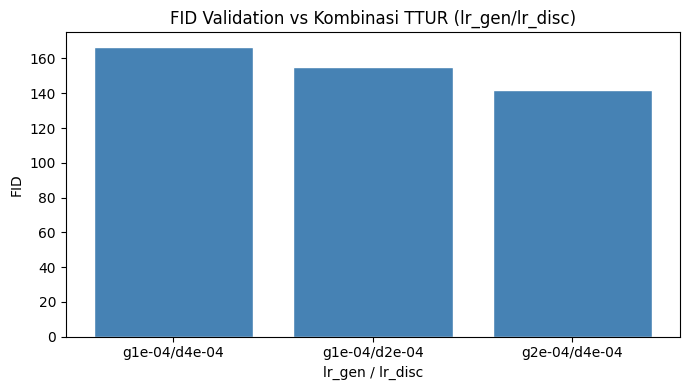

In [16]:
best_idx = df_tuning['FID (val)'].idxmin()
best_lr_gen, best_lr_disc = df_tuning.loc[best_idx, ['lr_gen', 'lr_disc']]
gen_final, disc_final = tuned_models[(best_lr_gen, best_lr_disc)]
fid_mod_tuned_val = df_tuning.loc[best_idx, 'FID (val)']
print(f'Kombinasi terbaik: lr_gen={best_lr_gen:.0e}, lr_disc={best_lr_disc:.0e} (FID val = {fid_mod_tuned_val:.2f})', flush=True)

fig = plt.figure(figsize=(7, 4))
labels_bar = [f'g{lr_gen:.0e}/d{lr_disc:.0e}' for lr_gen, lr_disc in zip(df_tuning['lr_gen'], df_tuning['lr_disc'])]
plt.bar(labels_bar, df_tuning['FID (val)'], color='steelblue', edgecolor='white')
plt.title('FID Validation vs Kombinasi TTUR (lr_gen/lr_disc)')
plt.xlabel('lr_gen / lr_disc'); plt.ylabel('FID')
plt.tight_layout()
plt.show()

Kombinasi `lr_gen=2e-4` / `lr_disc=4e-4` menghasilkan FID validasi terbaik (**141.81**).
Rasio TTUR yang lebih besar (Discriminator belajar 2x lebih cepat dari Generator) terbukti
memberi sinyal gradien yang lebih informatif, konsisten dengan prinsip TTUR bahwa Discriminator
perlu sedikit lebih maju dari Generator agar training lebih stabil.

### D.3 Evaluasi Akhir pada Test Set


Modified, sebelum tuning (test)   : FID = 168.85
Modified, sesudah tuning lr_gen=2e-04/lr_disc=4e-04 (test): FID = 144.28


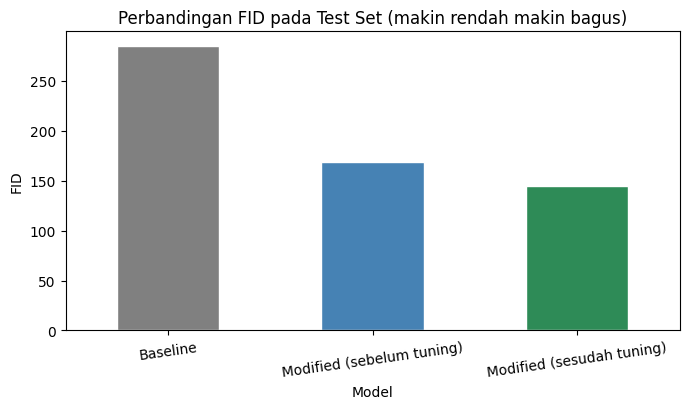

,FID (test)
Model,
Baseline,285.39
Modified (sebelum tuning),168.85
Modified (sesudah tuning),144.28


                           FID (test)
Model                                
Baseline                   285.391266
Modified (sebelum tuning)  168.854401
Modified (sesudah tuning)  144.276627


In [17]:
fid_mod_test = evaluate_fid(gen_mod, X_test, y_test, NOISE_DIM,
                             name='Modified, sebelum tuning (test)', output_range='tanh')
fid_final_test = evaluate_fid(gen_final, X_test, y_test, NOISE_DIM,
                               name=f'Modified, sesudah tuning lr_gen={best_lr_gen:.0e}/lr_disc={best_lr_disc:.0e} (test)',
                               output_range='tanh')

df_final = pd.DataFrame({
    'Model': ['Baseline', 'Modified (sebelum tuning)', 'Modified (sesudah tuning)'],
    'FID (test)': [fid_baseline, fid_mod_test, fid_final_test],
}).set_index('Model')

fig = plt.figure(figsize=(7, 4.2))
df_final['FID (test)'].plot(kind='bar', color=['gray', 'steelblue', 'seagreen'], edgecolor='white')
plt.title('Perbandingan FID pada Test Set (makin rendah makin bagus)')
plt.ylabel('FID'); plt.xticks(rotation=8)
plt.tight_layout()
plt.show()

display(df_final.style.format('{:.2f}'))
print(df_final, flush=True)

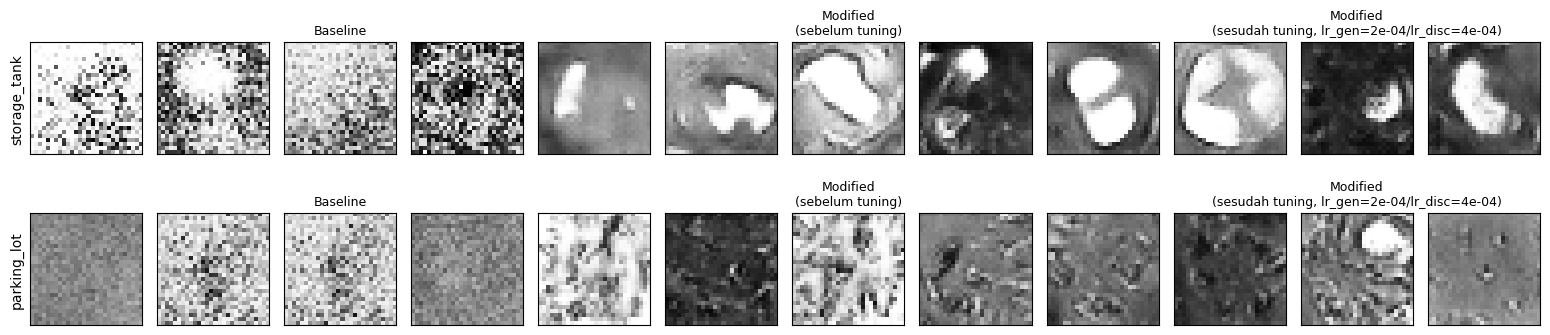

In [18]:
fig = compare_generated_grids([
    {'generator': gen_baseline, 'title': 'Baseline', 'output_range': 'unit'},
    {'generator': gen_mod, 'title': 'Modified\n(sebelum tuning)', 'output_range': 'tanh'},
    {'generator': gen_final, 'title': f'Modified\n(sesudah tuning, lr_gen={best_lr_gen:.0e}/lr_disc={best_lr_disc:.0e})', 'output_range': 'tanh'},
], NOISE_DIM)
plt.show()

**Kesimpulan**
- Lompatan terbesar dari Baseline ke Modified sebelum tuning (**-116.54**), membuktikan
  perubahan arsitektur ke DCGAN jauh lebih berpengaruh dibanding pemilihan hyperparameter
- Tuning TTUR memberikan penurunan tambahan (**-24.57**) yang tetap nyata dan konsisten
  dengan hasil validasi
- Citra sesudah tuning secara visual lebih tajam dan lebih konsisten per kelas dibanding
  dua model sebelumnya
- Angka FID masih relatif tinggi secara absolut karena dataset grayscale 28x28 dari foto
  udara memang berbeda jauh dari distribusi foto natural yang dipakai InceptionV3 sebagai
  basis perhitungan FID, sehingga perbandingan yang relevan tetap antar model, bukan
  terhadap angka FID benchmark dataset lain